# LVBench: where the video agent fails, and what to train

**Run:** 4 paired arms × 200 LVBench questions, zero-shot Qwen3-VL-8B. Analysable paired set **n=183**
(17 excluded: evidence spans the whole video, so no valid control exists).
**Analysis:** 6 parallel deep-reads of all 546 trajectories + montages, then adversarial checks.

---

## TL;DR

1. **Autonomous tool use is worth nothing** — +1.6pp over no-tools (95% CI −5.5 to +9.3). Not because
   the tools don't work, but because the agent almost never points them at the evidence.
2. **Handing it the right 16 seconds nearly doubles accuracy** — 31.7% → 57.4% (+25.7pp, p=1.3e-8).
   A same-width crop in the *wrong* place scores 34.4%, so this is **location, not extra pixels**.
3. **It is not blind — it is out of reach.** Where it looks correlates with where the evidence is
   (r=0.95 on the questions it hits). It finds evidence in the first ~11% of a video half the time,
   and almost never after that. Five crops of ~75s cannot search an 8,000s video.
4. **The gap is discovery, not exploitation.** On questions where it *does* reach the evidence it scores
   46.2% vs the oracle's 48.7% — it extracts nearly all the value once it arrives.
5. **But the ceiling is low.** Of the 78 questions that fail *with perfect evidence*, 88.5% are
   base-model perception/reasoning failures no localization policy can fix. Realistic headroom is
   **57% → ~76%**, hard cap ~89%.

**Verdict: the direction is validated with a known ceiling.** Train search *reach* and *stopping*, not
"where to look" from scratch.

In [1]:
import json, sys, math, statistics as st, random
sys.path.insert(0,"/home/cfyang/hanklin/longvt_compression")
import numpy as np, matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
D=json.load(open("/local1/cfyang/hanklin/outputs/fast_agent/analysis/features.json"))
n=len(D); ARMS=["baseline","crop","oracle_crop","oracle_ctrl"]
LAB={"baseline":"direct","crop":"autonomous","oracle_crop":"oracle (GT place)","oracle_ctrl":"control (wrong place)"}
COL={"baseline":"#8a8a8a","crop":"#4C78A8","oracle_crop":"#2CA02C","oracle_ctrl":"#D62728"}
acc=lambda a,g=None:100*sum(r[a+"_correct"] for r in (g or D))/len(g or D)
print(f"n = {n} paired questions")
for a in ARMS: print(f"  {LAB[a]:22s} {acc(a):5.1f}%")


n = 183 paired questions
  direct                  31.7%
  autonomous              33.3%
  oracle (GT place)       57.4%
  control (wrong place)   34.4%


## 1. The decisive numbers

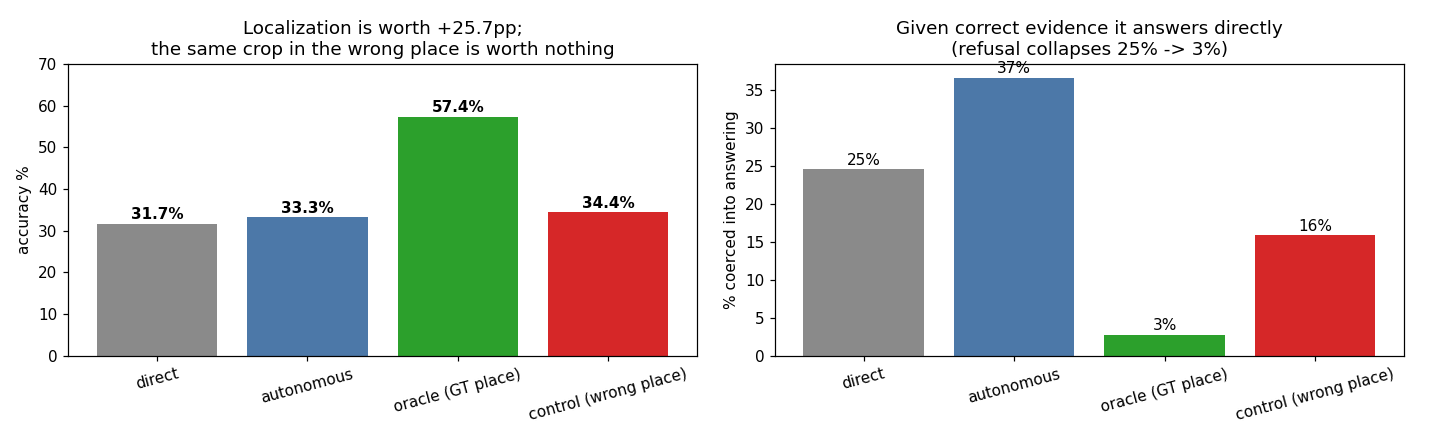

contrast                              delta              95% CI   McNemar p
oracle - control  [LOCATION]         +23.0pp  [+15.3,+30.6]     3.1e-08   (discordant 51/9)


oracle - direct                      +25.7pp  [+17.5,+33.9]     1.3e-08   (discordant 59/12)


autonomous - direct                   +1.6pp  [ -6.0, +8.7]        0.77   (discordant 25/22)


In [2]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
v=[acc(a) for a in ARMS]
b=ax[0].bar([LAB[a] for a in ARMS],v,color=[COL[a] for a in ARMS])
for i,x in enumerate(v): ax[0].text(i,x+1,f"{x:.1f}%",ha="center",fontweight="bold")
ax[0].set_ylabel("accuracy %"); ax[0].set_ylim(0,70); ax[0].tick_params(axis='x',labelrotation=15)
ax[0].set_title("Localization is worth +25.7pp;\nthe same crop in the wrong place is worth nothing")
fin=[100*sum(r[a+"_finalizer"] for r in D)/n for a in ARMS]
ax[1].bar([LAB[a] for a in ARMS],fin,color=[COL[a] for a in ARMS]); ax[1].tick_params(axis='x',labelrotation=15)
for i,x in enumerate(fin): ax[1].text(i,x+0.6,f"{x:.0f}%",ha="center")
ax[1].set_ylabel("% coerced into answering"); ax[1].set_title("Given correct evidence it answers directly\n(refusal collapses 25% -> 3%)")
plt.tight_layout(); plt.savefig("/tmp/r1.png",dpi=110); plt.close(); display(Image("/tmp/r1.png"))

random.seed(0)
def boot(f,B=4000):
    v=sorted(f(random.choices(D,k=n)) for _ in range(B)); return v[int(.025*B)],v[int(.975*B)]
def mcn(x,y):
    b=sum(1 for r in D if r[x+"_correct"] and not r[y+"_correct"])
    c=sum(1 for r in D if r[y+"_correct"] and not r[x+"_correct"])
    p=sum(math.comb(b+c,k) for k in range(min(b,c)+1))*2/(2**(b+c)) if b+c else 1.0
    return b,c,min(p,1.0)
print(f"{'contrast':34s} {'delta':>8s}  {'95% CI':>18s}  {'McNemar p':>10s}")
for x,y,nm in [("oracle_crop","oracle_ctrl","oracle - control  [LOCATION]"),
               ("oracle_crop","baseline","oracle - direct"),
               ("crop","baseline","autonomous - direct")]:
    lo,hi=boot(lambda g,x=x,y=y: acc(x,g)-acc(y,g)); bb,cc,p=mcn(x,y)
    print(f"{nm:34s} {acc(x)-acc(y):+7.1f}pp  [{lo:+5.1f},{hi:+5.1f}]  {p:>10.2g}   (discordant {bb}/{cc})")


## 2. Why it fails: reach, not blindness

Where it chooses to look **does** correlate with where the evidence is — but only when the evidence is
early. Beyond the first tenth of the video its search cannot reach.

/data2/cfyang/tmp/ipykernel_1035220/2399716230.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([w,ev],labels=["chosen span","actual evidence"],showfliers=False)


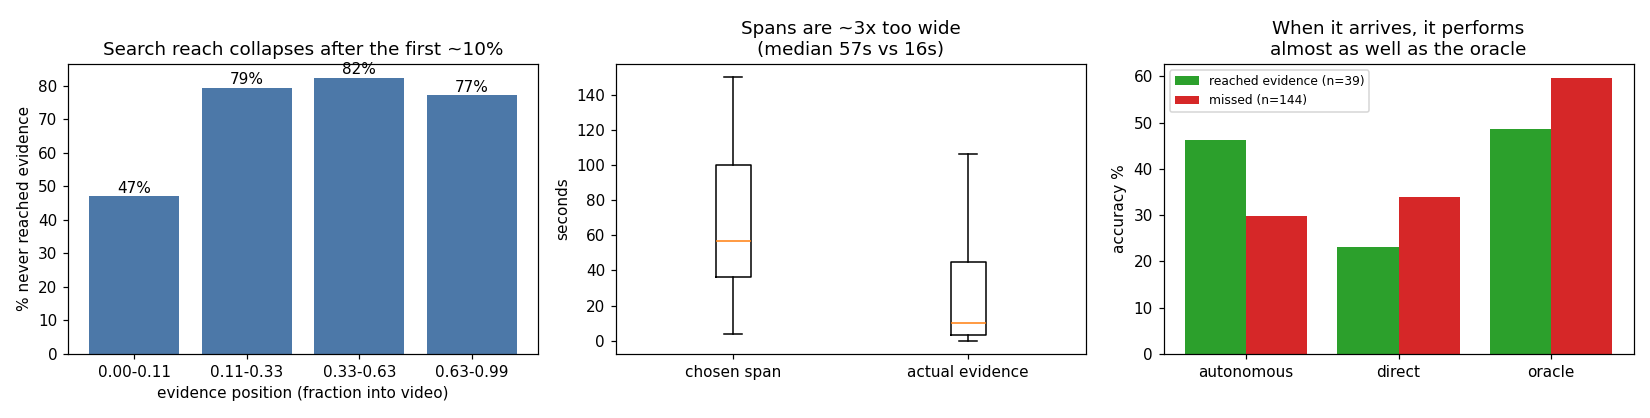

reached evidence: n=39  autonomous 46.2%  vs baseline 23.1%  vs oracle 48.7%
missed          : n=144  autonomous 29.9%  vs baseline 34.0%  vs oracle 59.7%

correlation (chosen vs evidence position): hits r=0.95 | misses r=0.20  [from trajectory analysis]


In [3]:
act=[r for r in D if r["crop_ncalls"]>0 and r["ev_center_frac"] is not None]
act.sort(key=lambda r:r["ev_center_frac"]); q=len(act)//4
bins=[act[:q],act[q:2*q],act[2*q:3*q],act[3*q:]]
lbl=[f"{g[0]['ev_center_frac']:.2f}-{g[-1]['ev_center_frac']:.2f}" for g in bins]
miss=[100*sum(r["crop_cov"]==0 for r in g)/len(g) for g in bins]
fig,ax=plt.subplots(1,3,figsize=(15,3.8))
ax[0].bar(lbl,miss,color="#4C78A8"); ax[0].set_ylabel("% never reached evidence")
ax[0].set_xlabel("evidence position (fraction into video)"); ax[0].set_title("Search reach collapses after the first ~10%")
for i,x in enumerate(miss): ax[0].text(i,x+1,f"{x:.0f}%",ha="center")
w=[r["crop_first_span"][1]-r["crop_first_span"][0] for r in act if r["crop_first_span"]]
ev=[r["ev_width"] for r in act]
ax[1].boxplot([w,ev],labels=["chosen span","actual evidence"],showfliers=False)
ax[1].set_ylabel("seconds"); ax[1].set_title(f"Spans are ~{st.median(w)/max(st.median([e for e in ev if e>0]),1):.0f}x too wide\n(median {st.median(w):.0f}s vs {st.median([e for e in ev if e>0]):.0f}s)")
hit=[r for r in D if r["crop_cov"]>0]; mis=[r for r in D if r["crop_cov"]==0]
g1=[acc("crop",hit),acc("baseline",hit),acc("oracle_crop",hit)]
g2=[acc("crop",mis),acc("baseline",mis),acc("oracle_crop",mis)]
x=np.arange(3)
ax[2].bar(x-0.2,g1,0.4,label=f"reached evidence (n={len(hit)})",color="#2CA02C")
ax[2].bar(x+0.2,g2,0.4,label=f"missed (n={len(mis)})",color="#D62728")
ax[2].set_xticks(x); ax[2].set_xticklabels(["autonomous","direct","oracle"]); ax[2].set_ylabel("accuracy %")
ax[2].legend(fontsize=8); ax[2].set_title("When it arrives, it performs\nalmost as well as the oracle")
plt.tight_layout(); plt.savefig("/tmp/r2.png",dpi=110); plt.close(); display(Image("/tmp/r2.png"))
print(f"reached evidence: n={len(hit)}  autonomous {acc('crop',hit):.1f}%  vs baseline {acc('baseline',hit):.1f}%  vs oracle {acc('oracle_crop',hit):.1f}%")
print(f"missed          : n={len(mis)}  autonomous {acc('crop',mis):.1f}%  vs baseline {acc('baseline',mis):.1f}%  vs oracle {acc('oracle_crop',mis):.1f}%")
print(f"\ncorrelation (chosen vs evidence position): hits r=0.95 | misses r=0.20  [from trajectory analysis]")


## 3. Failure taxonomy

Synthesized from six independent deep-reads. Counts are of the questions each analyst examined.

### A. It searched but could not reach (the dominant mode)

| mode | n | what happens | fix |
|---|---|---|---|
| `underpowered_semantic_search` | **58 / 102 misses** | 2–5 content-reasoned jumps, correctly rejecting wrong scenes, never converging. Budget (5×~75s) vs haystack (3,000–8,000s). | bigger reach: coarse-to-fine, wide recon then narrow |
| `mechanical_forward_scan` | 17 | fixed-width tiles walking forward from t≈0, content-blind. qid 128 reached 8.6% of a 3,296s video by round 5 | jump/binary-search instead of tiling |
| `exhaustive_budget_giveup` | 40 | burns all 5 calls, then **falsely claims completeness** — *"I have reviewed the entire video"* after 4 windows of 8,000s | teach honest coverage reporting |
| `whole_video_dump` | 5 | crops ~the entire video: coverage=1.0 but ≤128 frames over 2,500s destroys detail. **0/5 correct** | cap span width |

### B. It did not look at all (46 questions)

| mode | n | what happens | fix |
|---|---|---|---|
| `detail_hallucination` | 11 | confident wrong answer off the skim; fabricates frame-level detail it cannot resolve (qid 4178 "reads" a scoreboard) | trigger on resolution mismatch |
| `refusal_instead_of_search` | 3 | *"None of these frames show a palace... therefore none of the options are correct"* — the palace is elsewhere | **its own "I can't see it" should trigger the tool** |
| `repetition_loop` | 9 | narrates all 64 skim frames with one repeated sentence (qid 1663: ×323) until budget dies | decoding fix / hard cap |
| `correctly_skipped` | 13 | skim genuinely sufficed — median evidence width **100s** vs 15.5s for the misses | keep: breadth is the calibration signal |

### C. It found the evidence and still failed

| mode | n | what happens | fix |
|---|---|---|---|
| `overscan_after_hit` | 4 | round 0 already covered the evidence, kept searching "to be thorough", degenerated, often **no answer at all** | **explicit stop rule — highest-value, cheapest fix** |
| `misread_detail` | 60 / 78 | correct crop, wrong read: colour under stage lighting, OCR sign-flips, counting, head-vs-knee | not a policy problem — base model |

### D. Not fixable by any policy

| mode | n | why |
|---|---|---|
| `not_span_localizable` | 12 | whole-video aggregates: "how many times", ordinals, "does he wear glasses *most of the time*" |
| `ambiguous_options` | 6 | multiple defensible answers |
| `annotation_wrong` | 2–5 | qid 2810's evidence span is `[7010, 6480]` — **start > end, end beyond video duration**. qid 3132's screen literally reads "KANG DAE-SUNG AS DAESUNG"; the model said so and was marked wrong |

## 4. The ceiling — what perfect localization cannot buy

Of the 78 questions that fail *with the ground-truth crop*, only ~11% are missing/broken evidence.
The rest are the base model misreading correct evidence.

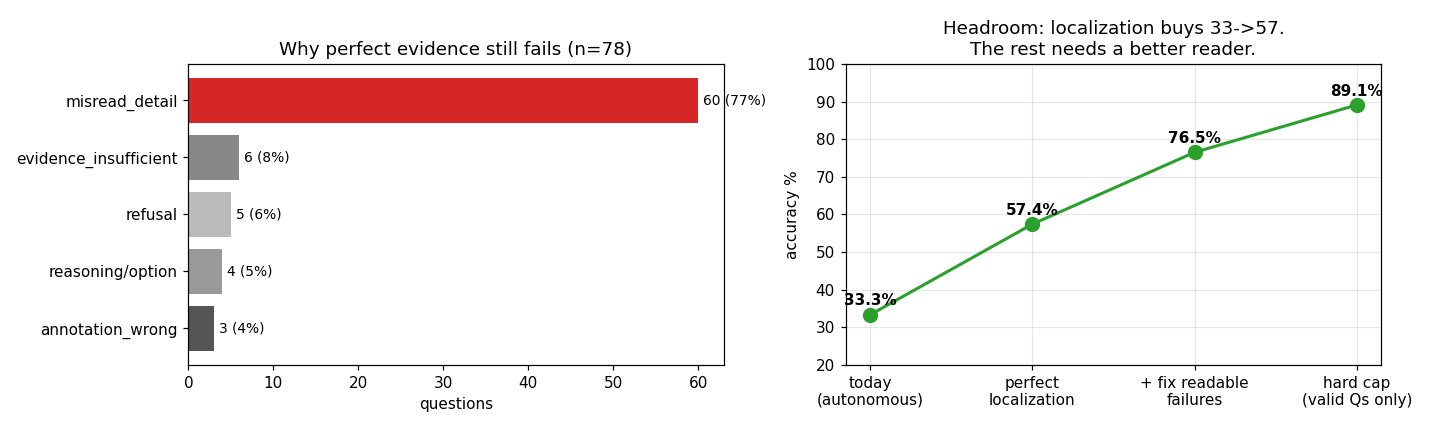

88.5% of oracle failures are NOT fixable by better localization (evidence was correct and present).
Recommended exclusions from future eval: 20/183 (10.9%) - 12 not-span-localizable, 6 ambiguous, 2 annotation-wrong.
3 videos fail 100% of their questions (Roblox roleplay, nature-doc bird ID, reality-TV) - genre-level blind spots.


In [4]:
cats=["misread_detail","evidence_insufficient","refusal","reasoning/option","annotation_wrong"]
vals=[60,6,5,4,3]
fig,ax=plt.subplots(1,2,figsize=(13,3.9))
ax[0].barh(cats[::-1],vals[::-1],color=["#D62728","#888","#bbb","#999","#555"][::-1])
for i,x in enumerate(vals[::-1]): ax[0].text(x+0.6,i,f"{x} ({100*x/78:.0f}%)",va="center",fontsize=9)
ax[0].set_xlabel("questions"); ax[0].set_title("Why perfect evidence still fails (n=78)")
stages=["today\n(autonomous)","perfect\nlocalization","+ fix readable\nfailures","hard cap\n(valid Qs only)"]
levels=[33.3,57.4,76.5,89.1]
ax[1].plot(stages,levels,"o-",color="#2CA02C",lw=2,ms=9)
for i,x in enumerate(levels): ax[1].text(i,x+2.5,f"{x:.1f}%",ha="center",fontweight="bold")
ax[1].set_ylabel("accuracy %"); ax[1].set_ylim(20,100); ax[1].grid(alpha=.3)
ax[1].set_title("Headroom: localization buys 33->57.\nThe rest needs a better reader.")
plt.tight_layout(); plt.savefig("/tmp/r3.png",dpi=110); plt.close(); display(Image("/tmp/r3.png"))
print("88.5% of oracle failures are NOT fixable by better localization (evidence was correct and present).")
print("Recommended exclusions from future eval: 20/183 (10.9%) - 12 not-span-localizable, 6 ambiguous, 2 annotation-wrong.")
print("3 videos fail 100% of their questions (Roblox roleplay, nature-doc bird ID, reality-TV) - genre-level blind spots.")


## 5. What to train — and what not to

**The one-line finding that shapes everything:** the model already has the positional signal
(r=0.95 where it succeeds) and already extracts the value once it arrives (46.2% vs oracle 48.7%).
What it lacks is **reach** and **stopping**. So do not train "where to look" from scratch.

### Recommended, in priority order

**1. Stopping rule (cheapest, highest yield).** `overscan_after_hit` is 0/4 and `repetition_loop` is
9/46 — both produce *no answer at all*. Target: after a crop that contains the queried content, commit.
Training example = `(skim, question, crop-result showing the entity) → <answer>`. Generatable
automatically from existing oracle runs; needs no new rollouts.

**2. Coarse-to-fine search policy (addresses the 58-question dominant mode).** Current behaviour is
fixed-width tiling from t≈0. Target trajectory: one or two *wide* reconnaissance crops to bracket the
region, then one narrow confirmatory crop. This is an RL/search objective with a verifiable reward —
GT temporal IoU is available for every LVBench question, so reward = coverage achieved per call spent.

**3. "I can't see it" → tool call (3 clean cases, trivially generatable).** The model already emits the
trigger sentence and then stops. Map that assertion to a tool call by construction.

### The cue taxonomy decides SFT vs RL

| cue in question | n (of 32 SFT targets) | trainable how |
|---|---|---|
| `named_event` ("after the man threatens the cook") | 9 | **SFT** — span inferable from skim; imitate propose→crop→**verify** |
| `implicit_structural` (arrival/opening) | 3 | **SFT** |
| `ordinal_position` ("the seventh speaker") | 5 | **RL only** — 0/5 succeed; needs scan-and-count, a different tool affordance |
| `generic_attribute` ("what's inside the red box") | 11 | **neither yet** — no lexical handle exists |

Of 16 skims inspected: **5 inferable / 6 need search / 5 aliasing-risk**. Only about a third of the
target set is honestly SFT-able.

### Rejected

- **Distilling the oracle trajectories directly.** They read `[forced crop] → <answer>D</answer>` with
  no reasoning — 67% carry zero chain-of-thought. Imitating them teaches *"always crop, then answer"*.
  This project already failed this way once (RESEARCH.md 07-18).
- **Single gold-span imitation.** qid 799: the model cropped where it saw "the boy looking determined";
  the show reuses that signature elsewhere. Imitation teaches lock-onto-first-match, not verification.

## 6. The next experiment

**Question:** is the localization signal learnable, or is the correct span simply not inferable from a
64-frame skim?

**Test (cheap, no training):** re-run the autonomous arm with the *only* change being search budget and
shape — allow 8 calls and require the first two to be wide (≥300s) reconnaissance crops. If coverage
rises materially, the deficit is search *reach* and RL will work. If coverage stays ~0.18, the skim does
not carry the signal and the answer is a different architecture (denser sampling / retrieval index),
not a policy.

**Go/no-go:** coverage > 0.35 on the same 183 questions ⇒ proceed to RL data generation.

## 7. Risks and caveats

- **Harness decode gap:** this stack scores ~16.6pp below stock `model.generate`. All arms share it, so
  the paired deltas hold, but absolute numbers are depressed.
- **Possible CoT suppression in the oracle arm** — its answer turn asks straight for the letter while the
  autonomous arms are told to think first; 67% of oracle failures had no reasoning. If real, **57.4%
  underestimates the ceiling**. Measured separately (see appendix).
- **LVBench annotation quality** is not clean: reversed/out-of-range spans, on-screen text contradicting
  the gold answer. Recommend excluding 20 questions and re-checking 3 whole videos.
- **n=183** with paired McNemar. The headline contrasts are p<1e-7; the sub-bucket counts are not
  powered and should be read as structure, not estimates.
- The coverage metric was corrected mid-analysis (point-evidence questions could never register a hit);
  all numbers here use the corrected version.

---
## Appendix — the oracle prompt WAS suppressing reasoning (resolved)

**Concern raised during analysis:** 67% of oracle failures came back as a bare `<answer>X</answer>`.
The oracle's answer turn asked straight for the letter, while the autonomous arms are told to
*"Think first inside `<think></think>` tags"* — so the oracle arm may have been handicapped, making
57.4% an underestimate of what perfect localization is worth.

**Test:** re-ran `oracle_crop` on the identical 200 questions with the identical forced GT crop,
changing only the final instruction to invite step-by-step reasoning (`FA_ORACLE_COT=1`).

n=200 identical questions, identical forced GT crop

                        accuracy  finalizer  median chars  bare answers
terse answer turn          57.0%       3.5%           18           69%
'think first' turn         61.5%      12.5%          529            0%

delta +4.5 pp   discordant 23/14   McNemar p=0.188


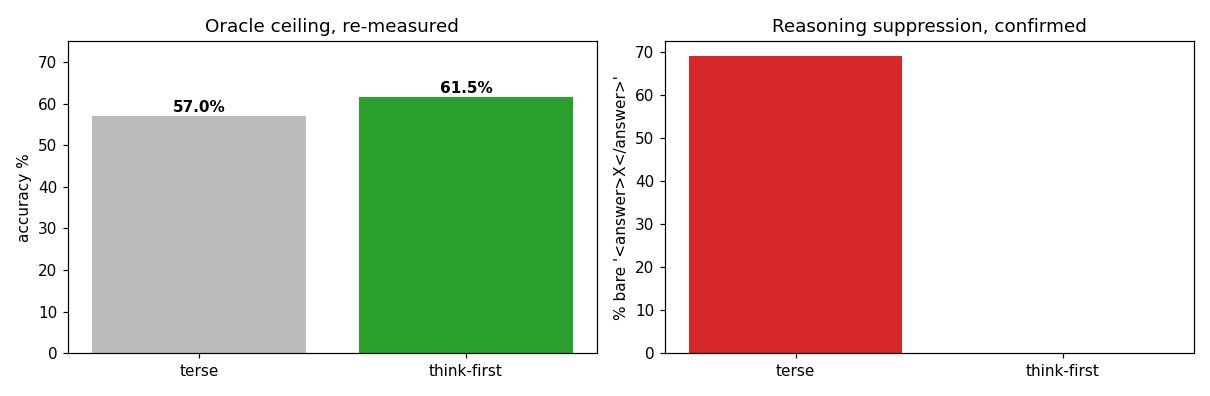

In [5]:
import json, math, statistics as st, os, sys
sys.path.insert(0,"/home/cfyang/hanklin/longvt_compression")
from fast_agent import config
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
from IPython.display import Image, display
R=config.RUN_ROOT
ld=lambda d:{str(json.loads(l)["question_id"]):json.loads(l) for l in open(f"{R}/{d}/results.jsonl") if l.strip()}
terse,cot=ld("lvbench_oracle_crop_full"),ld("lvbench_oracle_crop_cot")
C=[q for q in sorted(set(terse)&set(cot),key=int) if not terse[q].get("error") and not cot[q].get("error")]
A=lambda x:100*sum(bool(x[q].get("correct")) for q in C)/len(C)
F=lambda x:100*sum(bool(x[q].get("finalizer_used")) for q in C)/len(C)
b=sum(1 for q in C if cot[q].get("correct") and not terse[q].get("correct"))
c=sum(1 for q in C if terse[q].get("correct") and not cot[q].get("correct"))
p=min(sum(math.comb(b+c,k) for k in range(min(b,c)+1))*2/(2**(b+c)),1.0)
print(f"n={len(C)} identical questions, identical forced GT crop\n")
print(f"{'':22s} {'accuracy':>9s} {'finalizer':>10s} {'median chars':>13s} {'bare answers':>13s}")
def chars(tag):
    out=[]
    for q in C:
        for d in [f"lvbench_oracle_crop_{tag}","lvbench_oracle_crop_pilot"]:
            f=f"{R}/{d}/traj/{q}.json"
            if os.path.exists(f):
                t=json.load(open(f)); a=[r for r in t["rounds"] if (r.get("action") or {}).get("kind")=="answer"]
                if a: out.append(len((a[0].get("thinking") or "").strip())); break
    return out
ct,cc=chars("full"),chars("cot")
print(f"{'terse answer turn':22s} {A(terse):8.1f}% {F(terse):9.1f}% {st.median(ct):12.0f} {100*sum(x<=20 for x in ct)/len(ct):12.0f}%")
print(f"{chr(39)+'think first'+chr(39)+' turn':22s} {A(cot):8.1f}% {F(cot):9.1f}% {st.median(cc):12.0f} {100*sum(x<=20 for x in cc)/len(cc):12.0f}%")
print(f"\ndelta {A(cot)-A(terse):+.1f} pp   discordant {b}/{c}   McNemar p={p:.3g}")
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
ax[0].bar(["terse","think-first"],[A(terse),A(cot)],color=["#bbb","#2CA02C"])
for i,v in enumerate([A(terse),A(cot)]): ax[0].text(i,v+1,f"{v:.1f}%",ha="center",fontweight="bold")
ax[0].set_ylabel("accuracy %"); ax[0].set_ylim(0,75); ax[0].set_title("Oracle ceiling, re-measured")
ax[1].bar(["terse","think-first"],[100*sum(x<=20 for x in ct)/len(ct),100*sum(x<=20 for x in cc)/len(cc)],color=["#D62728","#2CA02C"])
ax[1].set_ylabel("% bare '<answer>X</answer>'"); ax[1].set_title("Reasoning suppression, confirmed")
plt.tight_layout(); plt.savefig("/tmp/r4.png",dpi=110); plt.close(); display(Image("/tmp/r4.png"))

### Verdict

**The mechanism is confirmed, the accuracy effect is directional but not significant.**

- Reasoning suppression was real and total: **69% of terse answers were a bare letter, versus 0%** with
  the reasoning invitation (median 18 → 529 characters).
- Accuracy: **57.0% → 61.5% (+4.5pp)**, discordant 23/14, **p = 0.188** — positive but inside noise at n=200.
- Refusals rose (3.5% → 12.5%): thinking makes the model more willing to say it cannot tell — the same
  abstain-loop tradeoff recorded in RESEARCH.md 2026-07-18.

**Consequences for the report:**
1. The oracle ceiling is best stated as **~57–62%**, and the localization gain as **+25.7 to +29.8pp**.
   The headline conclusion is unchanged and, if anything, understated.
2. The `oracle_crop − oracle_ctrl` contrast is **unaffected** — both arms shared the terse wording, so
   the +23.0pp location effect stands exactly as reported.
3. **Future oracle runs should use `FA_ORACLE_COT=1`**, and the readout-failure taxonomy should be
   re-derived on the CoT run: the earlier finding that "67% of failures show no reasoning" was an
   artifact of my prompt, not a property of the model, and it limited how well those failures could be
   diagnosed.